In [ ]:
!pip install pandas matplotlib seaborn --quiet

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Make all charts look sharp and professional
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'

print("✅ Libraries ready!")

✅ Libraries ready!


In [ ]:
df = pd.read_csv("applicant_behavior.csv")

print(f"✅ Dataset loaded — {df.shape[0]} rows, {df.shape[1]} columns")
print("\n── Column Overview ──")
print(df.dtypes)
print("\n── First 5 Rows ──")
df.head()

✅ Dataset loaded — 210 rows, 18 columns

── Column Overview ──
session_id                object
user_id                   object
age_group                 object
device_type               object
traffic_source            object
homepage_visited           int64
listings_browsed           int64
detail_page_viewed         int64
registration_attempted     int64
form_started               int64
application_submitted      int64
time_on_homepage_sec       int64
time_on_listings_sec       int64
time_on_detail_sec         int64
time_on_form_sec           int64
exit_page                 object
visit_date                object
internship_category       object
dtype: object

── First 5 Rows ──


,session_id,user_id,age_group,device_type,traffic_source,homepage_visited,listings_browsed,detail_page_viewed,registration_attempted,form_started,application_submitted,time_on_homepage_sec,time_on_listings_sec,time_on_detail_sec,time_on_form_sec,exit_page,visit_date,internship_category
0,S001,U001,18-22,Mobile,Google Search,1,1,1,1,1,1,45,120,95,310,submitted,2024-01-03,Data Science
1,S002,U002,23-26,Desktop,Direct,1,1,1,1,1,1,60,200,180,420,submitted,2024-01-03,Software Engineering
2,S003,U003,18-22,Mobile,Social Media,1,1,1,0,0,0,30,85,40,0,detail_page,2024-01-04,Marketing
3,S004,U004,18-22,Desktop,Google Search,1,1,0,0,0,0,25,60,0,0,listings,2024-01-04,Finance
4,S005,U005,23-26,Mobile,Email,1,1,1,1,1,1,55,140,160,390,submitted,2024-01-05,Data Science


In [ ]:
# Count how many users reached each step
funnel_steps = {
    'Homepage Visit':        df['homepage_visited'].sum(),
    'Browse Listings':       df['listings_browsed'].sum(),
    'View Detail Page':      df['detail_page_viewed'].sum(),
    'Registration':          df['registration_attempted'].sum(),
    'Started Application':   df['form_started'].sum(),
    'Submitted Application': df['application_submitted'].sum(),
}

funnel_df = pd.DataFrame({
    'Step': list(funnel_steps.keys()),
    'Users': list(funnel_steps.values())
})

# Calculate drop-off rate at each step
funnel_df['Conversion_Rate_%'] = (funnel_df['Users'] / funnel_df['Users'].iloc[0] * 100).round(1)
funnel_df['Drop_Off_%'] = (100 - funnel_df['Conversion_Rate_%']).round(1)
funnel_df['Users_Lost'] = funnel_df['Users'].iloc[0] - funnel_df['Users']

print("═" * 65)
print("             APPLICATION FUNNEL ANALYSIS")
print("═" * 65)
print(funnel_df.to_string(index=False))

# Identify the BIGGEST bottleneck
bottleneck_idx = funnel_df['Users_Lost'].idxmax()
bottleneck = funnel_df.loc[bottleneck_idx, 'Step']
print(f"\n🚨 BIGGEST BOTTLENECK: '{bottleneck}'")
print(f"   {funnel_df.loc[bottleneck_idx, 'Users_Lost']} users dropped off here")

═════════════════════════════════════════════════════════════════
             APPLICATION FUNNEL ANALYSIS
═════════════════════════════════════════════════════════════════
                 Step  Users  Conversion_Rate_%  Drop_Off_%  Users_Lost
       Homepage Visit    210              100.0         0.0           0
      Browse Listings    198               94.3         5.7          12
     View Detail Page    174               82.9        17.1          36
         Registration    134               63.8        36.2          76
  Started Application    105               50.0        50.0         105
Submitted Application     82               39.0        61.0         128

🚨 BIGGEST BOTTLENECK: 'Submitted Application'
   128 users dropped off here


In [ ]:
# SQL-Style Queries (Pandas = SQL for Python)

# ── Query 1: What is the overall application completion rate? ─
total_visitors = len(df)
total_submitted = df['application_submitted'].sum()
completion_rate = (total_submitted / total_visitors * 100).round(2)
print(f"📊 Q1: Overall Completion Rate: {completion_rate}%")
print(f"   {total_submitted} out of {total_visitors} visitors completed an application\n")

# ── Query 2: Which traffic source brings the most applicants? ─
source_conversion = df.groupby('traffic_source').agg(
    Total_Sessions=('session_id', 'count'),
    Applications_Submitted=('application_submitted', 'sum')
).reset_index()
source_conversion['Conversion_Rate_%'] = (
    source_conversion['Applications_Submitted'] / source_conversion['Total_Sessions'] * 100
).round(1)
source_conversion = source_conversion.sort_values('Conversion_Rate_%', ascending=False)
print("📊 Q2: Conversion Rate by Traffic Source:")
print(source_conversion.to_string(index=False))

# ── Query 3: Which device has the highest drop-off? ──────────
print("\n📊 Q3: Drop-off by Device Type:")
device_analysis = df.groupby('device_type').agg(
    Total_Users=('session_id','count'),
    Submitted=('application_submitted','sum')
).reset_index()
device_analysis['Drop_Off_%'] = (
    (1 - device_analysis['Submitted'] / device_analysis['Total_Users']) * 100
).round(1)
print(device_analysis.to_string(index=False))

# ── Query 4: Where do users exit most? ───────────────────────
print("\n📊 Q4: Top Exit Pages (where users leave):")
exit_analysis = df['exit_page'].value_counts().reset_index()
exit_analysis.columns = ['Exit_Page', 'User_Count']
exit_analysis['Percentage_%'] = (exit_analysis['User_Count'] / len(df) * 100).round(1)
print(exit_analysis.to_string(index=False))

# ── Query 5: Which department gets most applications? ────────
print("\n📊 Q5: Applications by Internship Category:")
cat_analysis = df.groupby('internship_category')['application_submitted'].sum().sort_values(ascending=False)
print(cat_analysis)

📊 Q1: Overall Completion Rate: 39.05%
   82 out of 210 visitors completed an application

📊 Q2: Conversion Rate by Traffic Source:
traffic_source  Total_Sessions  Applications_Submitted  Conversion_Rate_%
 Google Search              67                      35               52.2
         Email              35                      18               51.4
      LinkedIn              34                      16               47.1
        Direct              33                      12               36.4
  Social Media              41                       1                2.4

📊 Q3: Drop-off by Device Type:
device_type  Total_Users  Submitted  Drop_Off_%
    Desktop           82         47        42.7
     Mobile           95         28        70.5
     Tablet           33          7        78.8

📊 Q4: Top Exit Pages (where users leave):
   Exit_Page  User_Count  Percentage_%
   submitted          82          39.0
 detail_page          40          19.0
registration          29          13.8
  

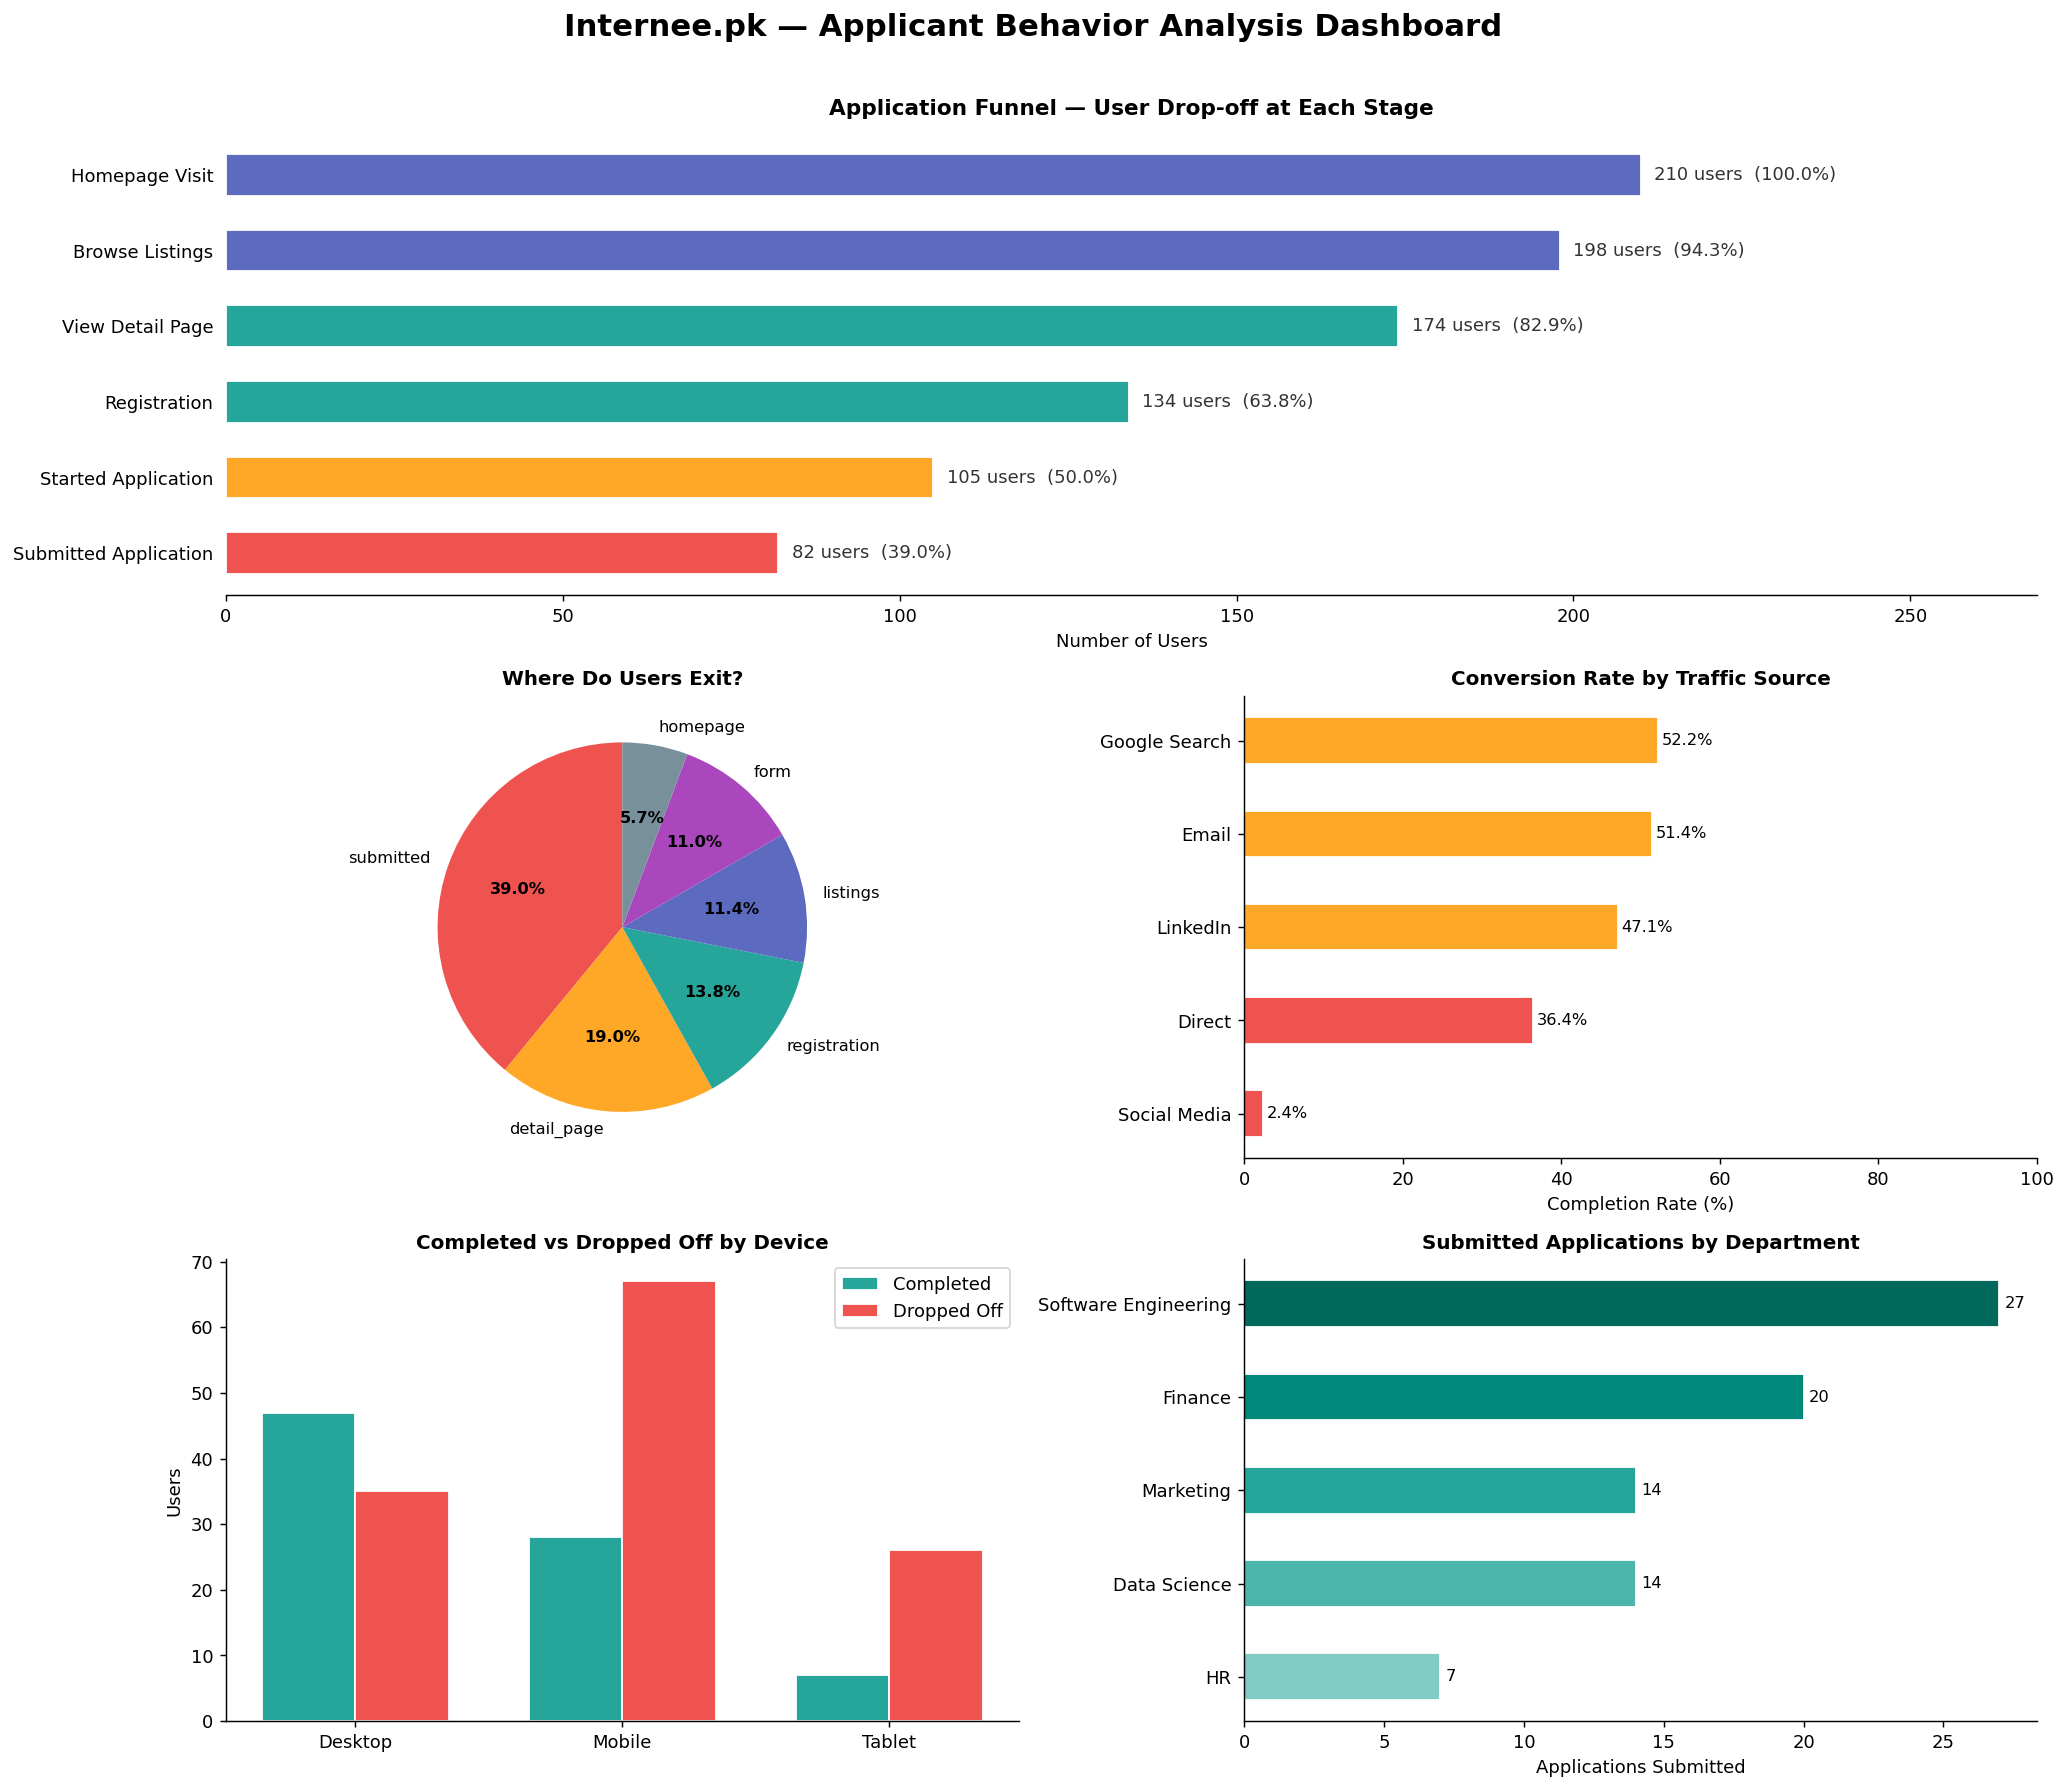

✅ Dashboard saved!


In [ ]:
# Professional Visualization Dashboard (Fixed)

fig = plt.figure(figsize=(16, 14))
fig.suptitle("Internee.pk — Applicant Behavior Analysis Dashboard",
             fontsize=17, fontweight='bold', y=0.98)

# ── Chart 1: Conversion Funnel ────────────────────────────────
ax1 = fig.add_subplot(3, 2, (1, 2))
colors_funnel = ['#5C6BC0','#5C6BC0','#26A69A','#26A69A','#FFA726','#EF5350']
bars = ax1.barh(funnel_df['Step'], funnel_df['Users'],
                color=colors_funnel, height=0.55, edgecolor='white')

# ✅ FIX: use .iloc[] instead of itertuples() to avoid column name issues
for i, bar in enumerate(bars):
    users = funnel_df['Users'].iloc[i]
    rate  = funnel_df['Conversion_Rate_%'].iloc[i]
    ax1.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
             f"{users} users  ({rate}%)",
             va='center', fontsize=10, fontweight='500', color='#333333')

ax1.set_xlim(0, funnel_df['Users'].max() * 1.28)
ax1.invert_yaxis()
ax1.set_title("Application Funnel — User Drop-off at Each Stage",
              fontweight='bold', fontsize=12, pad=10)
ax1.set_xlabel("Number of Users")
ax1.spines[['top','right','left']].set_visible(False)
ax1.tick_params(left=False)

# ── Chart 2: Exit Page Distribution ──────────────────────────
ax2 = fig.add_subplot(3, 2, 3)
exit_order = df['exit_page'].value_counts()
exit_colors = ['#EF5350','#FFA726','#26A69A','#5C6BC0','#AB47BC','#78909C']
wedges, texts, autotexts = ax2.pie(
    exit_order.values,
    labels=exit_order.index,
    autopct='%1.1f%%',
    colors=exit_colors[:len(exit_order)],
    startangle=90,
    textprops={'fontsize': 9}
)
for at in autotexts:
    at.set_fontweight('bold')
ax2.set_title("Where Do Users Exit?", fontweight='bold', fontsize=11)

# ── Chart 3: Conversion Rate by Traffic Source ────────────────
ax3 = fig.add_subplot(3, 2, 4)
source_sorted = source_conversion.sort_values('Conversion_Rate_%')
bar_colors_src = ['#EF5350' if x < 40 else '#FFA726' if x < 60 else '#26A69A'
                  for x in source_sorted['Conversion_Rate_%']]
bars3 = ax3.barh(source_sorted['traffic_source'], source_sorted['Conversion_Rate_%'],
                 color=bar_colors_src, height=0.5, edgecolor='white')
for bar in bars3:
    ax3.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
             f"{bar.get_width():.1f}%", va='center', fontsize=9)
ax3.set_xlim(0, 100)
ax3.set_title("Conversion Rate by Traffic Source", fontweight='bold', fontsize=11)
ax3.set_xlabel("Completion Rate (%)")
ax3.spines[['top','right']].set_visible(False)

# ── Chart 4: Device Type — Completed vs Dropped Off ──────────
ax4 = fig.add_subplot(3, 2, 5)
device_pivot = df.groupby('device_type').agg(
    Submitted=('application_submitted', 'sum'),
    Not_Submitted=('application_submitted', lambda x: (x == 0).sum())
).reset_index()
x = range(len(device_pivot))
width = 0.35
ax4.bar([i - width/2 for i in x], device_pivot['Submitted'],
        width, label='Completed', color='#26A69A', edgecolor='white')
ax4.bar([i + width/2 for i in x], device_pivot['Not_Submitted'],
        width, label='Dropped Off', color='#EF5350', edgecolor='white')
ax4.set_xticks(list(x))
ax4.set_xticklabels(device_pivot['device_type'])
ax4.set_title("Completed vs Dropped Off by Device", fontweight='bold', fontsize=11)
ax4.set_ylabel("Users")
ax4.legend()
ax4.spines[['top','right']].set_visible(False)

# ── Chart 5: Applications by Department ───────────────────────
ax5 = fig.add_subplot(3, 2, 6)
dept_apps = df.groupby('internship_category')['application_submitted'].sum().sort_values()
bars5 = ax5.barh(dept_apps.index, dept_apps.values,
                 color=['#80CBC4','#4DB6AC','#26A69A','#00897B','#00695C'],
                 height=0.5, edgecolor='white')
for bar in bars5:
    ax5.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
             str(int(bar.get_width())), va='center', fontsize=9)
ax5.set_title("Submitted Applications by Department", fontweight='bold', fontsize=11)
ax5.set_xlabel("Applications Submitted")
ax5.spines[['top','right']].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("behavior_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved!")

In [ ]:
# Business Insights & Recommendations

print("=" * 65)
print("        KEY INSIGHTS & RECOMMENDATIONS")
print("=" * 65)

# Auto-generate insights from data
submitted = df['application_submitted'].sum()
total = len(df)
rate = round(submitted/total*100, 1)

top_source = source_conversion.iloc[0]['traffic_source']
top_source_rate = source_conversion.iloc[0]['Conversion_Rate_%']

worst_device = device_analysis.sort_values('Drop_Off_%', ascending=False).iloc[0]
best_dept = df.groupby('internship_category')['application_submitted'].sum().idxmax()

exit_top = df['exit_page'].value_counts().index[0]

print(f"""
📌 INSIGHT 1 — Overall Conversion Rate
   Only {rate}% of visitors complete an application.
   ➜ Recommendation: Set a target of 25%+ and A/B test the form.

📌 INSIGHT 2 — Biggest Drop-off Point
   Most users exit at: '{exit_top}'
   ➜ Recommendation: Simplify this step — reduce fields,
     add progress indicators, or add a 'Save & Continue Later' button.

📌 INSIGHT 3 — Best Performing Traffic Source
   '{top_source}' has the highest conversion rate ({top_source_rate}%).
   ➜ Recommendation: Increase marketing budget for this channel.

📌 INSIGHT 4 — Device Drop-off Problem
   '{worst_device['device_type']}' users have the highest drop-off ({worst_device['Drop_Off_%']}%).
   ➜ Recommendation: Audit the application form on this device.
     Ensure buttons, fields, and layout are mobile-friendly.

📌 INSIGHT 5 — Most Popular Internship Category
   '{best_dept}' receives the most completed applications.
   ➜ Recommendation: Create more listings in this category
     and use it as an anchor in homepage promotions.
""")

        KEY INSIGHTS & RECOMMENDATIONS

📌 INSIGHT 1 — Overall Conversion Rate
   Only 39.0% of visitors complete an application.
   ➜ Recommendation: Set a target of 25%+ and A/B test the form.

📌 INSIGHT 2 — Biggest Drop-off Point
   Most users exit at: 'submitted'
   ➜ Recommendation: Simplify this step — reduce fields,
     add progress indicators, or add a 'Save & Continue Later' button.

📌 INSIGHT 3 — Best Performing Traffic Source
   'Google Search' has the highest conversion rate (52.2%).
   ➜ Recommendation: Increase marketing budget for this channel.

📌 INSIGHT 4 — Device Drop-off Problem
   'Tablet' users have the highest drop-off (78.8%).
   ➜ Recommendation: Audit the application form on this device.
     Ensure buttons, fields, and layout are mobile-friendly.

📌 INSIGHT 5 — Most Popular Internship Category
   'Software Engineering' receives the most completed applications.
   ➜ Recommendation: Create more listings in this category
     and use it as an anchor in homepage p

In [ ]:
# Save Results & Download

# Save enriched data
df['completed_funnel'] = df['application_submitted'].apply(
    lambda x: 'Completed' if x == 1 else 'Dropped Off'
)
df.to_csv("behavior_analysis_results.csv", index=False)

# Save funnel summary
funnel_df.to_csv("funnel_summary.csv", index=False)

# Download all files
from google.colab import files
files.download("behavior_analysis_results.csv")
files.download("funnel_summary.csv")
files.download("behavior_dashboard.png")

print("✅ All files downloaded!")
print("""
── Files you now have ──────────────────────────────
  📄 applicant_behavior.csv          Raw dataset
  📄 behavior_analysis_results.csv   Enriched results
  📄 funnel_summary.csv              Funnel table
  📊 behavior_dashboard.png          Visual dashboard
""")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded!

── Files you now have ──────────────────────────────
  📄 applicant_behavior.csv          Raw dataset
  📄 behavior_analysis_results.csv   Enriched results
  📄 funnel_summary.csv              Funnel table
  📊 behavior_dashboard.png          Visual dashboard

